## Question 1

In [1]:
import matplotlib.pyplot as plt
from separate import compute_iteration

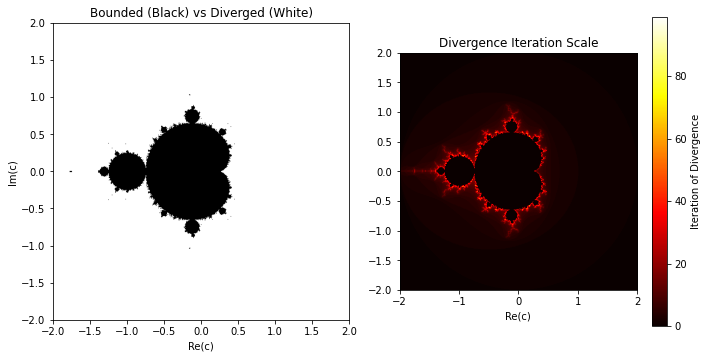

In [2]:
div_step, bdd_mask = compute_iteration(-2, 2, -2, 2, 100)

# First image required
plt.figure(figsize = (10,5))
plt.subplot(1, 2, 1)
plt.imshow(bdd_mask, extent=(-2, 2, -2, 2), cmap='binary')
plt.title("Bounded (Black) vs Diverged (White)")
plt.xlabel("Re(c)")
plt.ylabel("Im(c)")

# Second image required
plt.subplot(1, 2, 2)
plt.imshow(div_step, extent=(-2, 2, -2, 2), cmap='hot')
plt.colorbar(label='Iteration of Divergence')
plt.title("Divergence Iteration Scale")
plt.xlabel("Re(c)")

plt.tight_layout()
plt.show()

## Question 2

In [3]:
import numpy as np
from scipy.integrate import solve_ivp

### Part 1, 2, & 3

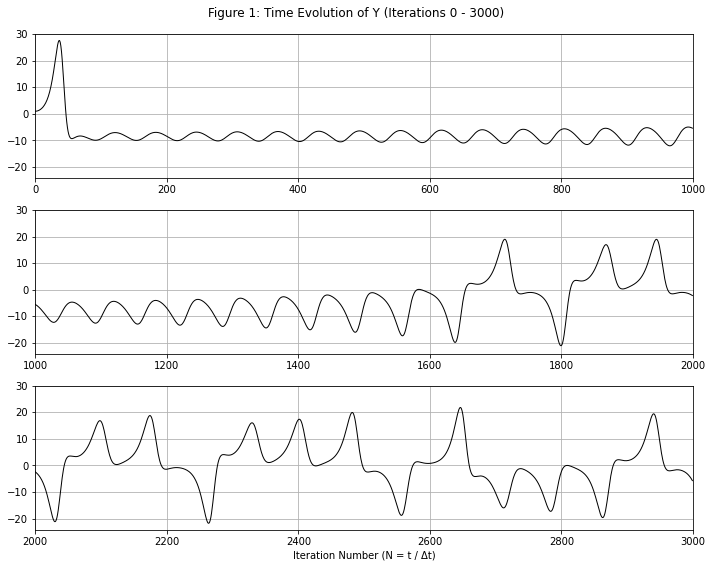

In [5]:
def lorenz_equations(t, W, sigma, r, b):
    """
    Computes the Lorenz equations 25, 26, 27 outlined in assignment 3
    
    Parameters:
    t -- float representing the current time 
    W -- array that represents the current state vector [X, Y, Z]
    sigma -- float, Prandtl number (ratio of kinematic viscosity to 
    thermal diffusivity)
    b -- float, dimensionless length scale
    r -- float, Rayleigh number
    
    Returns:
    list of derivatives 
    """
    X, Y, Z = W
    return [-sigma * (X - Y), r * X - Y - X * Z, -b * Z + X * Y]

sigma, r, b = 10.0, 28.0, 8.0/3.0
W0 = np.array([0.0, 1.0, 0.0])

t_span = (0, 60)
delta_t = 0.01
t_eval = np.arange(t_span[0], t_span[1], delta_t)

# Solve using numerical integration (part 2)

solution = solve_ivp(lorenz_equations, t_span, W0, args=(sigma, r, b), 
                t_eval=t_eval, rtol=1e-10, atol=1e-11)

X, Y, Z = solution.y


# Reproduce figure 1 (part 3)
fig1, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharey=True)

# Iterations 0 to 1000
ax1.plot(np.arange(0, 1000), Y[0:1000], color='black', lw=1)
ax1.set_xlim(0, 1000)
ax1.grid(True)

# Iterations 1000 to 2000
ax2.plot(np.arange(1000, 2000), Y[1000:2000], color='black', lw=1)
ax2.set_xlim(1000, 2000)
ax2.grid(True)

# Iterations 2000 to 3000
ax3.plot(np.arange(2000, 3000), Y[2000:3000], color='black', lw=1)
ax3.set_xlim(2000, 3000)
ax3.grid(True)

fig1.suptitle("Figure 1: Time Evolution of Y (Iterations 0 - 3000)")
ax3.set_xlabel("Iteration Number (N = t / Δt)")
plt.tight_layout()
plt.show()

### Part 4

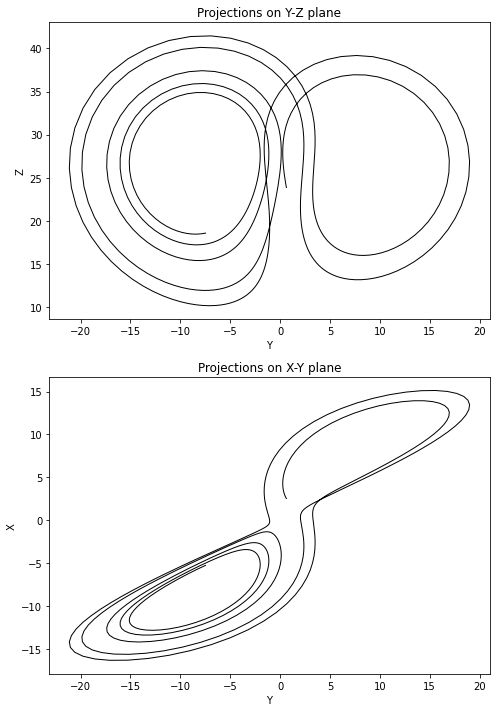

In [6]:
start, end = 1400, 1900
fig2, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(7, 10))

# Phase Space Projection Z vs Y
ax_top.plot(Y[start:end], Z[start:end], color='black', lw=1)
ax_top.set_ylabel("Z")
ax_top.set_xlabel("Y")
ax_top.set_title("Projections on Y-Z plane")

# Phase Space Projection X vs Y
ax_bottom.plot(Y[start:end], X[start:end], color='black', lw=1)
ax_bottom.set_ylabel("X")
ax_bottom.set_xlabel("Y")
ax_bottom.set_title("Projections on X-Y plane")

plt.tight_layout()
plt.show()

### Part 5

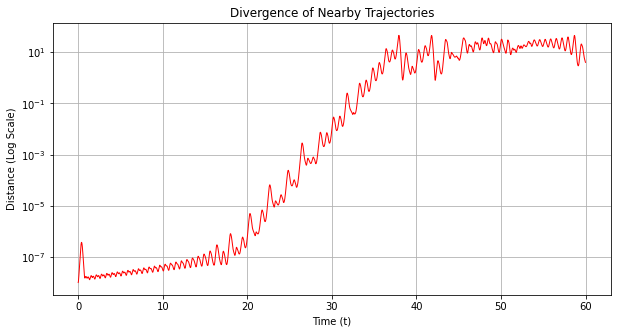

In [8]:
W0_prime = W0 + np.array([0.0, 1e-8, 0.0])

solution_prime = solve_ivp(lorenz_equations, t_span, W0_prime, args=(sigma, r, b), 
                      t_eval=t_eval, rtol=1e-10, atol=1e-11)

X_diff = solution.y[0] - solution_prime.y[0]
Y_diff = solution.y[1] - solution_prime.y[1]
Z_diff = solution.y[2] - solution_prime.y[2]
dist = np.sqrt(X_diff**2 + Y_diff**2 + Z_diff**2)

plt.figure(figsize=(10, 5))
plt.semilogy(solution.t, dist, color='red', lw=1)
plt.title("Divergence of Nearby Trajectories")
plt.xlabel("Time (t)")
plt.ylabel("Distance (Log Scale)")
plt.grid(True)
plt.show()